In [23]:
import sys 
import os
import json
import numpy as np

sys.path.append(os.path.abspath(".."))
from metrics import MetricEvaluator
from metrics import plot_cases, all_cases, load_nii, print_matrix

## Metrics
For autoPETV we opt for simplified setup with 2 metrics. The overlapping DSC, similar to previous iterations and a new detection metric which is an aggregated F1 detection score. For this score we sum all true positives, false negatives and false positives across all cases and then calculate the F1 score. Detection is based on an overlap criterion, threshold $\tau$ and an assignement strategy, in our case inter section over union (IoU),  $\tau=0.1$ and we do not punish multiassignment.

Since we use different test datasets in our challenge all metrics will be calculated per subset and then averaged.

To get started we prepared some examples. The first case has to perfect matches and one lesion, which has less overlap than $IoU=0.1$. In the previous challenges this would still have produced an FNV of 0 but now this will be counted as one false negative (fn) and one false positive (fp). The second case has two clear error lesions one fp and on fn. The third case is an empty case with an fp. And the last case showcases how multiassignement is handled.


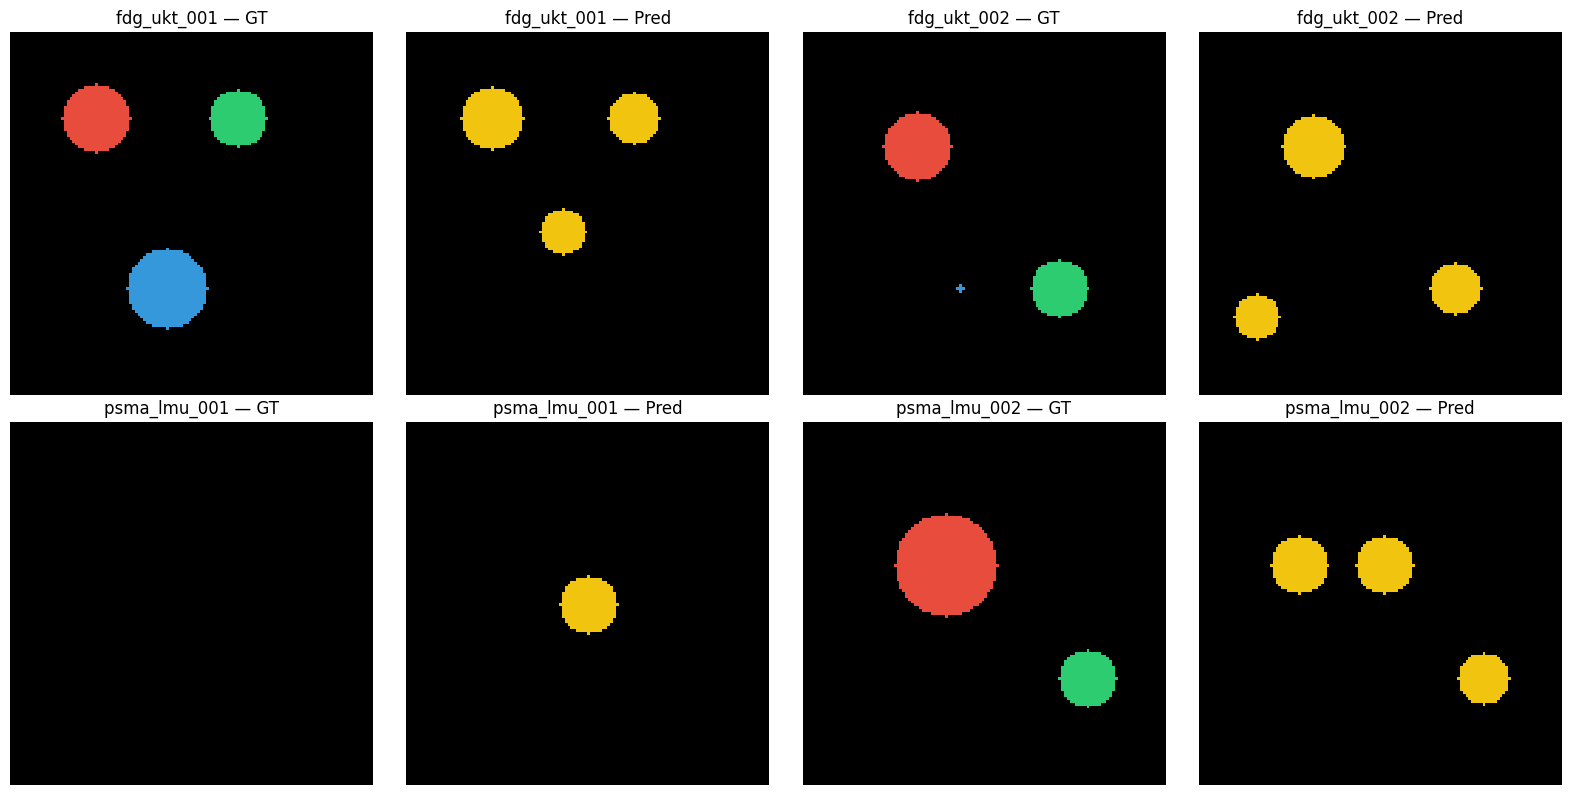

In [24]:
plot_cases()

We provide an MetricEvaluator class to quickly calculate the metrics. The class call function expects the prediction and ground truth as binarized numpy array. If you want to calculate FNV and FPV we also need to provide the voxel spacing. If you want to safe the sample results and metadata you just need to pass a save directory during initialization. 

In [25]:
evaluator = MetricEvaluator(overlap_threshold=0.1, connectivity=18, save_dir=None)
 
for gt, pred, name in all_cases():
    tmp = evaluator(pred, gt, name, spacing=[1,1,1])
    print(name, json.dumps(tmp, sort_keys=True, indent=4))

fdg_ukt_001 {
    "dsc": 0.48650093557872226,
    "f1": 0.6666666666666666,
    "fn": 1,
    "fnv": 0.0,
    "fp": 1,
    "fpv": 0.0,
    "tp": 2
}
fdg_ukt_002 {
    "dsc": 0.9212310902451748,
    "f1": 0.6666666666666666,
    "fn": 1,
    "fnv": 0.005,
    "fp": 1,
    "fpv": 0.197,
    "tp": 2
}
psma_lmu_001 {
    "dsc": NaN,
    "f1": NaN,
    "fn": 0,
    "fnv": NaN,
    "fp": 1,
    "fpv": 0.317,
    "tp": 0
}
psma_lmu_002 {
    "dsc": 0.7098814229249012,
    "f1": 1.0,
    "fn": 0,
    "fnv": 0.0,
    "fp": 0,
    "fpv": 0.0,
    "tp": 2
}


To aggregate metrics we can use two different modes. Aggregate over all samples or weight by dataset. For per dataset weigthing the case names need to follow the convention **tracer_center_** XYZ.

In [26]:
print("\n=== Unweighted ===")
print(evaluator.aggregate(weighted=False))

print("\n=== Dataset-weighted ===")
print(evaluator.aggregate(weighted=True))


=== Unweighted ===
{'dsc': 0.7058711495829327, 'f1_aggregated': 0.7058823529411765}

=== Dataset-weighted ===
{'dsc_weighted': 0.7068737179184248, 'f1_aggregated_weighted': 0.7333333333333334}


## Extra 
We provide some extra tooling to simplify lesion analyis. If you return the meta data you can reconstruct an intersection matrix and correlate detections with lesion size and uptake (if you provide the suv).

In [27]:
gt, pred, name = all_cases()[0]
meta = MetricEvaluator()(pred, gt, name, spacing=[1,1,1], suv=gt, return_meta=True)
meta

{'dsc': [(1, 1, np.float64(0.921760391198044)),
  (2, 2, np.float64(0.887719298245614)),
  (3, 3, np.float64(0.022222222222222223))],
 'tp': 2,
 'fp': 1,
 'fn': 1,
 'f1': 0.6666666666666666,
 'fpv': np.float64(0.0),
 'fnv': np.float64(0.0),
 'num_gt_instances': 3,
 'num_pred_instances': 3,
 'iou': [(1, 1, np.float64(0.854875283446712)),
  (2, 2, np.float64(0.7981072555205048)),
  (3, 3, np.float64(0.011235955056179775))],
 'gt_volume': [441, 317, 613],
 'pred_volume': [377, 253, 197],
 'spacing': [1.0, 1.0, 1.0],
 'gt_suv_max': [np.uint8(1), np.uint8(2), np.uint8(3)],
 'pred_suv_max': [np.uint8(1), np.uint8(2), np.uint8(3)]}

In [28]:
overlap_matrix = np.zeros((meta["num_gt_instances"], meta["num_pred_instances"]))
for i, j, iou in meta["iou"]:
    overlap_matrix[i - 1, j - 1] = iou
    
print_matrix(overlap_matrix)
print(f"\nExample GT lesion 3; SUV: {meta['gt_suv_max'][3-1]}, VOL: {meta['gt_volume'][3-1] * np.prod(meta['spacing']) / 1000 } mL")

    P1        P2        P3     
G1  0.855     0.000     0.000  
G2  0.000     0.798     0.000  
G3  0.000     0.000     0.011  

Example GT lesion 3; SUV: 3, VOL: 0.613 mL


If you provide the ground truth as instance map ie every lesion has a different integer number (by applying cc3d with 18 connectivity once to all gts) you can track lesions between experiments (case gts are all ready instances in this example). Concrete then G1 to Gn will always have the same index, however predictions will change. This comes in handy if you wanna track if your model improves for lesions with specific characteristics. For example the difficult ones are often small and have low uptake. You can also simply modify the Metric class to include other lesion characteristics like, organ location etc. Just be aware of the optimizations we make. Volumes are cropped to another shape (self.suv = suv[self.crop_shape]) and lesion matches are compressed in a list of pairs. 